# BABA Stock Prediction: predicting next-day close with an LSTM

This notebook walks through a complete deep-learning pipeline for predicting the next trading-day **closing price** of Alibaba (ticker **BABA**, NYSE) from the last 60 days of historical prices. From the raw download to the final evaluation, every step is here, executable cell by cell.

### Why this problem is hard

Stock prices are a **non-stationary time series**: the mean, variance, and underlying market regime all drift over time (BABA in particular went through three very different regimes between 2015 and today). A surprisingly tough benchmark to beat is the trivial baseline that predicts *"tomorrow = today"*, the so-called **naive baseline**. Any model worth its complexity has to be at least as accurate as that, in dollars.

### Why an LSTM

Daily prices form a sequence where order is everything. We need a model that respects sequence order **and** can carry information across many time steps. A **Long Short-Term Memory (LSTM)** network is the canonical choice: it's a recurrent neural network with an explicit memory cell and three gates that decide what to forget, what to write, and what to expose. A dedicated section just before the model code goes deeper into the intuition.

### What this notebook does

1. Downloads the price history.
2. Explores the series visually (price, volume, returns).
3. Computes the naive baseline as a reference floor.
4. Preprocesses the data into scaled, windowed training samples.
5. Builds and trains the LSTM.
6. Evaluates it in real dollars and compares against the naive baseline.
7. Saves the model and scaler so they can be served by the REST API in `src/api/`.

The notebook **imports** the same functions used by the production code in `src/`, so what you see here is exactly what would run end-to-end in a production training job. No code duplication.

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.config import DATA, MODEL, RAW_PARQUET, MODEL_PATH, SCALER_PATH
from src.data.fetch import fetch
from src.data.preprocess import build_splits
from src.model.architecture import build_lstm
from src.model.evaluate import all_metrics

print(f'Symbol: {DATA.symbol} | Lookback: {MODEL.lookback} days | Target: {DATA.target_col}')

Symbol: BABA | Lookback: 60 days | Target: Close


## Data collection

We download daily OHLCV history for BABA via the `yfinance` library and persist it locally as Parquet. The fetch is idempotent: it skips the download if the file is already on disk.

**Choices and why:**

- **Ticker: BABA (Alibaba, NYSE)** — ~11 years of daily history (≈ 2,800 rows) crossing several market regimes (2015–18 growth, 2020 COVID shock, 2021 China-tech crackdown, 2022–25 recovery). Enough variety to train, small enough to iterate fast on CPU.
- **Data range: 2015-01-01 → today** — gives the model exposure to multiple regimes, which generalises better than a single calm period.
- **Source: `yfinance`** — free, no API key required, returns OHLCV directly.
- **Storage: Parquet** — columnar and compressed, ≈ 10× smaller and faster to read than CSV; first-class support in pandas/pyarrow.

In [2]:
if not RAW_PARQUET.exists():
    fetch()
df = pd.read_parquet(RAW_PARQUET).set_index('Date').sort_index()
print(f'{len(df)} trading days | {df.index.min().date()} -> {df.index.max().date()}')
df.head()

2859 trading days | 2015-01-02 -> 2026-05-15


,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2015-01-02,98.388405,103.599998,104.720001,102.519997,104.239998,12303400
2015-01-05,95.919189,101.000000,103.019997,99.900002,102.760002,18337000
2015-01-06,98.122482,103.320000,103.849998,100.110001,101.250000,15720400
2015-01-07,96.992348,102.129997,104.739998,102.029999,104.589996,11052200
2015-01-08,99.746475,105.029999,105.339996,102.680000,102.949997,12942100


## EDA: Price and volume

Quick look at the series. BABA shows three clear regimes: growth through 2020, regulatory crash in 2021-22, and partial recovery since then.

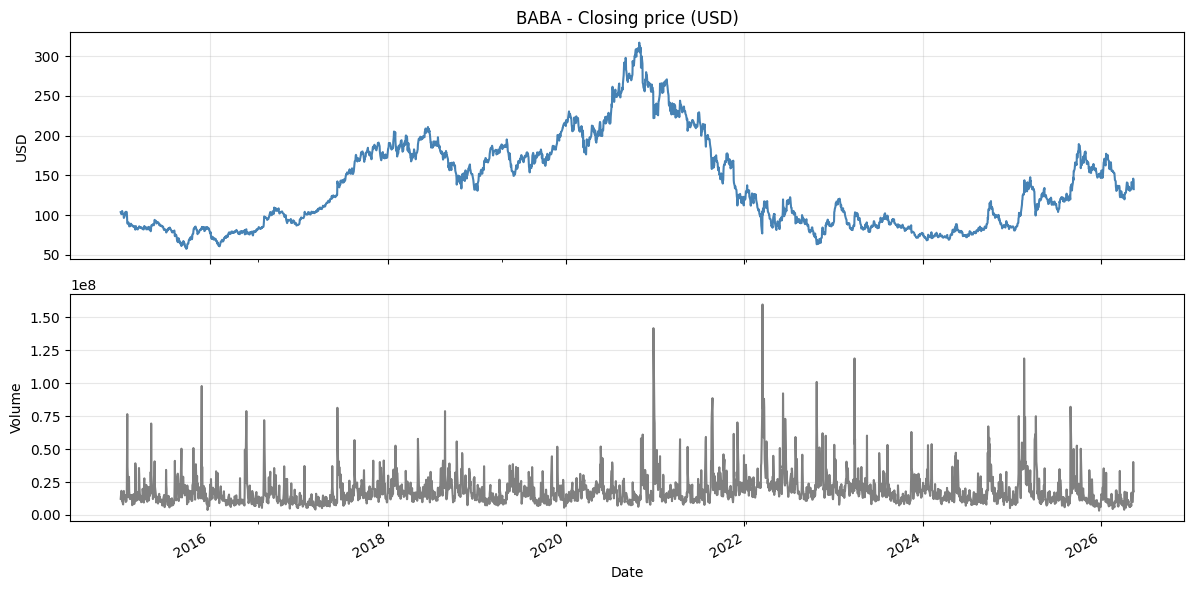

In [3]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
df['Close'].plot(ax=ax1, color='steelblue')
ax1.set_title(f'{DATA.symbol} - Closing price (USD)')
ax1.set_ylabel('USD'); ax1.grid(alpha=0.3)
df['Volume'].plot(ax=ax2, color='gray')
ax2.set_ylabel('Volume'); ax2.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## EDA: Daily returns (stationarity)

Price is non-stationary. Daily returns (percentage change) are close to stationary, oscillating around zero, an important property for statistical models.

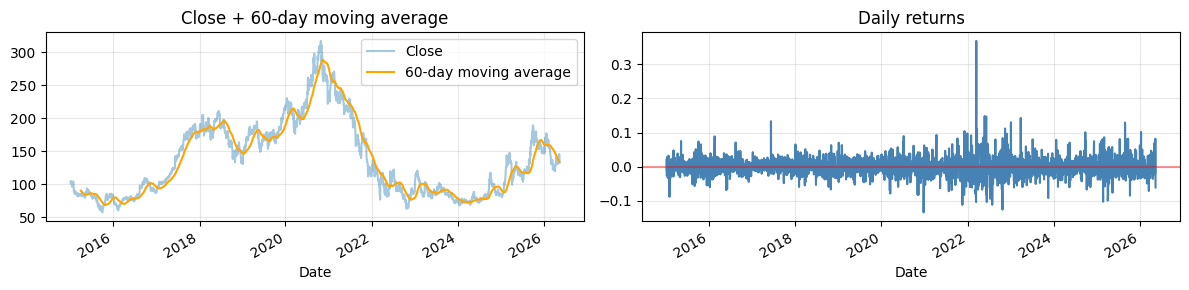

Mean return: 0.0438% | Std: 2.6743%


In [4]:
rets = df['Close'].pct_change().dropna()
fig, ax = plt.subplots(1, 2, figsize=(12, 3))
df['Close'].plot(ax=ax[0], alpha=0.4, label='Close')
df['Close'].rolling(60).mean().plot(ax=ax[0], label='60-day moving average', color='orange')
ax[0].legend(); ax[0].set_title('Close + 60-day moving average'); ax[0].grid(alpha=0.3)
rets.plot(ax=ax[1], color='steelblue')
ax[1].set_title('Daily returns'); ax[1].axhline(0, color='red', alpha=0.4); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()
print(f'Mean return: {rets.mean():.4%} | Std: {rets.std():.4%}')

## Naive baseline: "tomorrow's price = today's price"

A regression metric in isolation tells you almost nothing. *"MAE = 4 dollars"* is meaningless until you know what a trivial baseline scores. Here we compute the simplest possible baseline (predict yesterday's close) and use it as the **floor** that any model must, at minimum, come close to.

In [5]:
close = df['Close'].values
naive_metrics = all_metrics(close[1:], close[:-1])
print('Naive baseline (y_hat = y_{t-1}):')
for k, v in naive_metrics.items():
    unit = '%' if k == 'mape' else 'USD'
    print(f'  {k.upper():5s} = {v:7.3f} {unit}')

Naive baseline (y_hat = y_{t-1}):
  MAE   =   2.484 USD
  RMSE  =   3.688 USD
  MAPE  =   1.845 %


## Preprocessing: scaling, windowing, chronological split

The function `build_splits()` in `src/data/preprocess.py` does three things in one call.

**Choices and why:**

- **Target: `Close` (univariate)** — predicting the closing price is the classic textbook formulation and lets us focus on the model architecture itself. Adding `Volume` or macro features (multivariate) is a natural extension.
- **Scaling: `MinMaxScaler` fitted *only* on the training set** — LSTM gates use `sigmoid`/`tanh` activations, which converge much faster on bounded inputs. Fitting on training data only avoids leaking future information (the min/max of the test period) back into the model.
- **Sliding-window length: 60 trading days** — about one calendar quarter. Long enough to capture short and medium-term patterns, short enough to keep the training set big.
- **Split: 70 / 15 / 15 chronological** — train on the oldest 70 %, validate on the next 15 %, test on the most recent 15 %. **Never shuffled.** Shuffling a time series leaks the future into the training set, producing impressive but worthless metrics.

In [6]:
splits = build_splits(df=df.reset_index(), lookback=MODEL.lookback)
scaler = splits.scaler
print(f'Shapes (samples, lookback, features):')
print(f'  X_train: {splits.X_train.shape} | y_train: {splits.y_train.shape}')
print(f'  X_val:   {splits.X_val.shape} | y_val:   {splits.y_val.shape}')
print(f'  X_test:  {splits.X_test.shape} | y_test:  {splits.y_test.shape}')
print(f'\nMinMaxScaler: feature_range={scaler.feature_range} | data_min={scaler.data_min_[0]:.2f} | data_max={scaler.data_max_[0]:.2f}')

2026-05-20 14:57:59,814 INFO Shapes — train (1941, 60, 1) val (428, 60, 1) test (430, 60, 1)


Shapes (samples, lookback, features):
  X_train: (1941, 60, 1) | y_train: (1941,)
  X_val:   (428, 60, 1) | y_val:   (428,)
  X_test:  (430, 60, 1) | y_test:  (430,)

MinMaxScaler: feature_range=(0, 1) | data_min=57.39 | data_max=317.14


## Why an LSTM?

Our input is a sequence (60 daily closing prices) and our output depends on the **order** in those days. We need a model that does not treat the 60 inputs as a bag of unordered numbers.

A **Recurrent Neural Network (RNN)** processes a sequence one step at a time, carrying a hidden state from one step to the next that summarises everything it has seen so far. That's exactly the right shape for our problem.

The catch: plain RNNs suffer from the **vanishing-gradient problem**. As the network is trained, gradient signals shrink (or explode) when propagated back through many time steps, so the model effectively forgets the distant past after only a handful of steps.

The **Long Short-Term Memory** network, introduced by Hochreiter & Schmidhuber in 1997, solves this with a dedicated **cell state** that flows through the sequence almost untouched, controlled by three small gates:

- **Forget gate** — what to drop from the cell state.
- **Input gate** — what new information to write to it.
- **Output gate** — what to expose as the hidden state for the next step.

Result: an LSTM can carry information across **dozens to hundreds of time steps**, which is exactly the regime we need to detect multi-month patterns in daily stock prices.

## Model architecture

Defined in `src/model/architecture.py:build_lstm()`:

```
Input(60, 1)
  -> LSTM(50, return_sequences=True) -> Dropout(0.2)
  -> LSTM(50)                        -> Dropout(0.2)
  -> Dense(1)
```

Compiled with the `Adam` optimizer (learning rate `1e-3`), `MSE` loss and `MAE` as a tracked metric.

**Choices and why:**

- **Two stacked LSTM(50) layers** — a standard "two-layer LSTM with dropout" template. 50 units is a sane midpoint: large enough to capture the signal, small enough to train in seconds on CPU.
- **Dropout(0.2) between layers** — during training, 20 % of activations are randomly zeroed. Cheap regularization that prevents the network from over-relying on any single neuron, fighting overfitting.
- **Dense(1) on top** — single output neuron, no activation (regression). The output is the next-day's scaled closing price.
- **Framework: TensorFlow / Keras** — first-class native `.keras` save format, mature MLflow integration, and the most widely understood API for this kind of architecture.

In [7]:
import tensorflow as tf
tf.keras.utils.set_random_seed(MODEL.random_seed)

model = build_lstm()
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,651 (119.73 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

## Training

Train the model for real: up to 50 epochs, ~1 minute on CPU. Two callbacks ride along.

**Choices and why:**

- **Loss: `MSE` (Mean Squared Error)** — differentiable everywhere and penalises large errors quadratically. Standard for regression.
- **Optimizer: `Adam(lr=1e-3)`** — adaptive per-weight learning rate. Robust default that works without much tuning.
- **Mini-batch size: 32** — small enough to give noisy-but-frequent gradient updates (good for generalisation), large enough that each epoch still runs in a few seconds.
- **Seed: 42** — `random.seed`, `np.random.seed`, `tf.random.set_seed` are all set in `src/model/train.py`. Makes runs reproducible (within the limits of GPU non-determinism).
- **`EarlyStopping(patience=10, restore_best_weights=True)`** — stops training when `val_loss` does not improve for 10 consecutive epochs and rolls the weights back to the best-seen version. Prevents both overfitting and wasted compute.
- **`ModelCheckpoint`** — writes the best model to disk on every `val_loss` improvement. Insurance against process crashes.

In [8]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

callbacks = [
    EarlyStopping(monitor='val_loss', patience=MODEL.early_stop_patience, restore_best_weights=True),
    ModelCheckpoint(filepath=str(MODEL_PATH), monitor='val_loss', save_best_only=True),
]

history = model.fit(
    splits.X_train, splits.y_train,
    validation_data=(splits.X_val, splits.y_val),
    epochs=MODEL.epochs,
    batch_size=MODEL.batch_size,
    callbacks=callbacks,
    verbose=2,
)

Epoch 1/50


61/61 - 3s - 43ms/step - loss: 0.0157 - mae: 0.0806 - val_loss: 4.2155e-04 - val_mae: 0.0147


Epoch 2/50


61/61 - 1s - 16ms/step - loss: 0.0030 - mae: 0.0393 - val_loss: 4.0785e-04 - val_mae: 0.0151


Epoch 3/50


...

61/61 - 1s - 15ms/step - loss: 8.6855e-04 - mae: 0.0215 - val_loss: 1.9382e-04 - val_mae: 0.0103


Epoch 49/50


61/61 - 1s - 16ms/step - loss: 9.0307e-04 - mae: 0.0218 - val_loss: 1.4040e-04 - val_mae: 0.0085


Epoch 50/50


61/61 - 1s - 15ms/step - loss: 8.9973e-04 - mae: 0.0216 - val_loss: 1.3134e-04 - val_mae: 0.0086


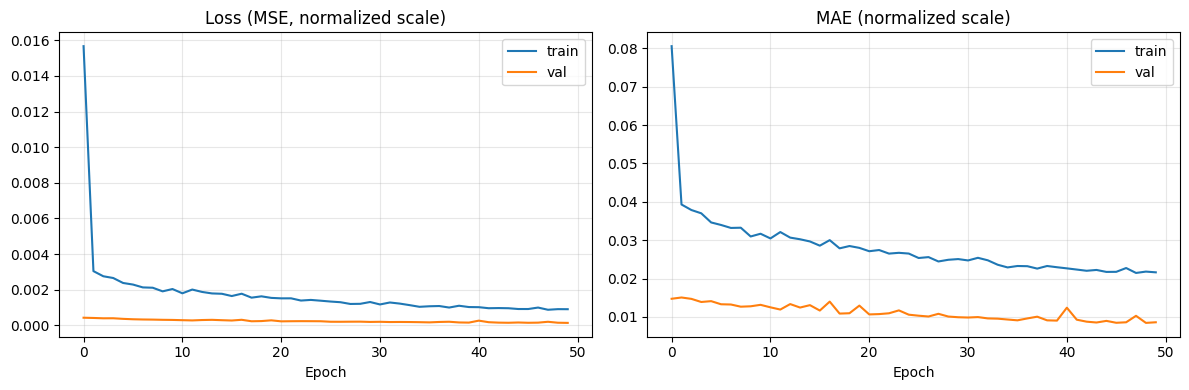

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(history.history['loss'], label='train')
ax[0].plot(history.history['val_loss'], label='val')
ax[0].set_title('Loss (MSE, normalized scale)')
ax[0].set_xlabel('Epoch'); ax[0].legend(); ax[0].grid(alpha=0.3)
ax[1].plot(history.history['mae'], label='train')
ax[1].plot(history.history['val_mae'], label='val')
ax[1].set_title('MAE (normalized scale)')
ax[1].set_xlabel('Epoch'); ax[1].legend(); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Evaluation on the test set

Predictions are first inverse-scaled (back to dollars) and only then fed into the metrics. This means every number below is **directly interpretable** on the price axis.

We compute three complementary metrics from `src/model/evaluate.py:all_metrics()`:

- **MAE** (Mean Absolute Error, in USD) — average dollar error.
- **RMSE** (Root Mean Squared Error, in USD) — same units as MAE but punishes big errors more. The gap between RMSE and MAE tells you whether errors are uniform or have heavy tails.
- **MAPE** (Mean Absolute Percentage Error, in %) — average percentage error. Scale-free, so it can be compared across different stocks.

We also re-print the **naive baseline** numbers right next to the LSTM's, because the only honest way to judge our model is to compare against the floor. A MAPE around 3 % sounds great until you remember the naive baseline can be at 2-4 % on a series like BABA: the LSTM should match or improve on it, never lose to it.

In [10]:
y_pred_scaled = model.predict(splits.X_test, verbose=0).ravel()
y_pred = scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()
y_true = scaler.inverse_transform(splits.y_test.reshape(-1, 1)).ravel()

metrics = all_metrics(y_true, y_pred)
print('Test-set metrics (original USD scale):')
for k, v in metrics.items():
    unit = '%' if k == 'mape' else 'USD'
    print(f'  {k.upper():5s} = {v:7.3f} {unit}')

print('\nComparison with naive baseline:')
for k in metrics:
    delta = metrics[k] - naive_metrics[k]
    sign = 'down - better' if delta < 0 else 'up - worse'
    unit = '%' if k == 'mape' else 'USD'
    print(f'  {k.upper():5s}  LSTM {metrics[k]:7.3f} vs naive {naive_metrics[k]:7.3f}  ({delta:+.3f} {unit} {sign})')

Test-set metrics (original USD scale):
  MAE   =   3.749 USD
  RMSE  =   5.043 USD
  MAPE  =   2.943 %

Comparison with naive baseline:
  MAE    LSTM   3.749 vs naive   2.484  (+1.265 USD up - worse)
  RMSE   LSTM   5.043 vs naive   3.688  (+1.355 USD up - worse)
  MAPE   LSTM   2.943 vs naive   1.845  (+1.099 % up - worse)


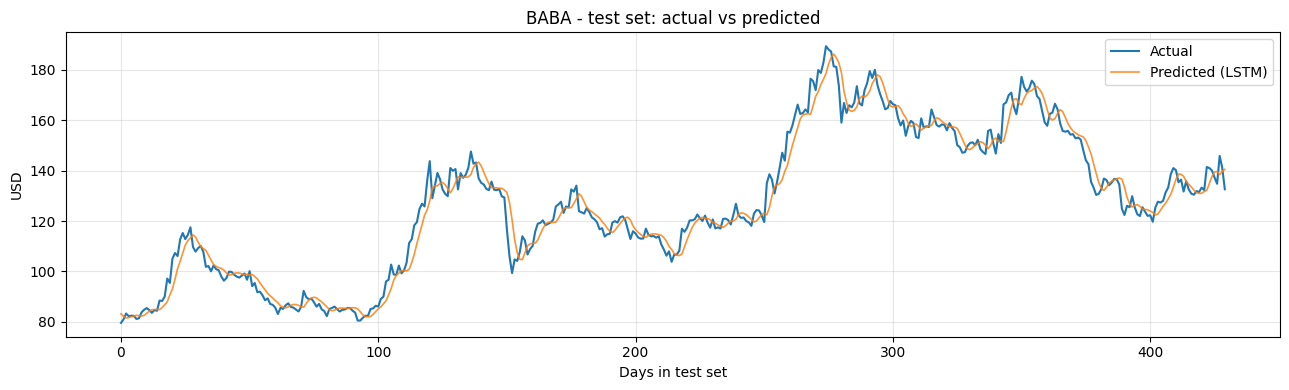

In [11]:
plt.figure(figsize=(13, 4))
plt.plot(y_true, label='Actual', linewidth=1.5)
plt.plot(y_pred, label='Predicted (LSTM)', alpha=0.85, linewidth=1.2)
plt.title(f'{DATA.symbol} - test set: actual vs predicted')
plt.ylabel('USD'); plt.xlabel('Days in test set')
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Saving model and scaler

We persist **two** artifacts under `models/`, and the serving code needs both at inference time:

- **`lstm_baba.keras`** — the trained network (weights + architecture) in Keras v3's native format, the recommended replacement for the legacy `.h5`.
- **`scaler.pkl`** — the fitted `MinMaxScaler`, serialised with `joblib`. The API uses it at request time to scale incoming prices into `[0, 1]` before the model sees them, then to inverse-scale the prediction back into dollars.

They must always be shipped **as a pair from the same training run**. If you retrain and replace one without the other, the scales drift and the network produces garbage in production.

In [12]:
import joblib

model.save(MODEL_PATH)
joblib.dump(scaler, SCALER_PATH)

print(f'Model saved to: {MODEL_PATH}  ({MODEL_PATH.stat().st_size / 1024:.1f} KB)')
print(f'Scaler saved to: {SCALER_PATH}  ({SCALER_PATH.stat().st_size / 1024:.1f} KB)')

Model saved to: C:\Users\vitor\Documents\POS\4\baba-stock-prediction\models\lstm_baba.keras  (395.0 KB)
Scaler saved to: C:\Users\vitor\Documents\POS\4\baba-stock-prediction\models\scaler.pkl  (0.7 KB)


## Serving the model with a REST API

The REST API that serves the saved model lives in `src/api/` (`main.py`, `schemas.py`, `inference.py`, `middleware.py`).

Exposed endpoints:

| Method | Route             | What it does |
|--------|-------------------|--------------|
| GET    | `/health`         | Healthcheck: confirms the model is loaded. |
| POST   | `/predict`        | Takes 60 closing prices, returns the next predicted close. |
| POST   | `/predict/latest` | Pulls the last 60 days from Yahoo Finance and predicts the next close. |
| POST   | `/train`          | Kicks off a training run (blocks ~1 min), logs to MLflow, hot-reloads the in-process model. |
| GET    | `/metrics`        | Counters and latency percentiles (p50/p95/p99). |

To run locally:

```bash
uvicorn src.api.main:app --reload
# -> http://localhost:8000/docs
```

**Choices and why:**

- **FastAPI** — async framework with built-in `pydantic` validation, auto-generated OpenAPI/Swagger UI at `/docs`, and clean middleware support.
- **Container base: `python:3.12-slim`** — smallest stable base with full Python; TensorFlow 2.18 wheels are available for `linux/amd64` + Python 3.12.
- **Host port `8010` mapped to container port `8000`** — host `8000` was already taken by another container on the dev machine. The container itself still listens on the canonical `8000`.

There is also a `Dockerfile` + `docker-compose.yml` at the repo root that spin up the full stack (API + MLflow server) with `docker compose up`.

## Monitoring and experiment tracking

Two observability surfaces, one for training, one for serving.

**Training-time: MLflow.** When training is fired through the API's `POST /train` endpoint (see "Serving the model with a REST API" above), the run is registered in MLflow with hyperparameters, per-epoch metrics, test-set metrics, and the model as an artifact. With the `docker compose` stack up, the MLflow UI lives at `http://localhost:5000`.

**Serving-time: structured logs + `/metrics` endpoint.** The middleware in `src/api/middleware.py` emits one **JSON log line** per request (`request_id`, route, status, latency) and feeds a 1,000-entry latency ring buffer exposed via `GET /metrics` as p50/p95/p99/mean per route.

**Choices and why:**

- **MLflow + JSON logs + `/metrics`** — MLflow covers training-time observability (which experiment beat which); the middleware + endpoint cover serving-time observability (is the API healthy, how fast is it). Lightweight, no external SaaS dependency.
- **Latency percentiles, not just mean** — `p95` is the number you put in an SLO ("only 1 in 20 requests is slower than this"). The mean hides slow outliers and is misleading on its own.

---

**End of the notebook.** From here, the next steps would be experimenting with multivariate inputs, predicting returns instead of price, and walk-forward backtesting — all listed under "Honest caveats" in the project README.